# Notebook 04 — DBSCAN, Algorithm Comparison & Recommendation Demo

**Objective:** Introduce DBSCAN as a density-based alternative to K-Means,
compare both algorithms using intrinsic clustering metrics, and demonstrate
the recommendation engine on a real profile.

**Inputs:**
- `data/processed/X_processed.npy` — feature matrix from notebook 02
- `data/raw/profiles.csv` — original profiles for display layer
- `data/processed/cluster_labels.npy` — K-Means labels from notebook 03

**Outputs:**
- `outputs/plots/11_dbscan_grid_search.png` — DBSCAN parameter heatmap
- `outputs/plots/12_algorithm_comparison.png` — side-by-side metrics bar chart
- `outputs/plots/13_tsne_comparison.png` — t-SNE coloured by each algorithm
- `outputs/clusters/dbscan_cluster_*.csv` — DBSCAN cluster CSVs

## 0. Setup & Imports

In [ ]:
import os
import sys

NOTEBOOK_DIR = os.path.abspath("")
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.config import (
    RAW_DATA_PATH, PROCESSED_PATH, PLOTS_DIR,
    PCA_COMPONENTS,
)
from src.models.clustering import (
    run_dbscan_experiment,
    plot_dbscan_results,
    fit_final_dbscan,
    profile_clusters,
)
from src.models.compatibility import recommend_profiles
from src.evaluation.intrinsic_metrics import evaluate_clustering, compare_algorithms

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"
warnings.filterwarnings("ignore")
print("Imports complete")

In [ ]:
X = np.load(PROCESSED_PATH)
print(f"Feature matrix shape : {X.shape}")

df_original = pd.read_csv(RAW_DATA_PATH)
print(f"Profiles loaded      : {len(df_original):,}")

kmeans_labels = np.load(os.path.join(PROJECT_ROOT, "data", "processed",
                                      "cluster_labels.npy"))
print(f"K-Means labels loaded: {len(kmeans_labels):,}  (K={len(np.unique(kmeans_labels))})")

vocab_path = os.path.join(PROJECT_ROOT, "data", "processed", "skill_vocab.txt")
with open(vocab_path) as f:
    skill_vocab = [line.strip() for line in f.readlines()]
print(f"Skill vocabulary     : {len(skill_vocab)} terms")

## 1. Prepare PCA Space (shared by both algorithms)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions  : {X.shape[1]}")
print(f"PCA dimensions       : {X_pca.shape[1]}")
print(f"Variance retained    : {pca.explained_variance_ratio_.sum()*100:.2f}%")

## 2. DBSCAN — Density-Based Clustering

Unlike K-Means, DBSCAN does not require specifying the number of clusters.
It groups points that are densely packed together and marks outliers as noise.

**Key parameters:**
- `eps` — maximum distance between two points to be considered neighbours
- `min_samples` — minimum points required to form a dense region (core point)

**Why DBSCAN for this problem:**
- Can discover clusters of arbitrary shape (K-Means assumes spherical)
- Naturally identifies outliers / noise profiles that don't fit any group
- No need to guess K in advance

In [5]:
dbscan_results = run_dbscan_experiment(
    X_pca,
    eps_values=[0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6],
    min_samples_values=[5, 10, 20, 50],
    n_components=8
)

  Reduced to 8 components for DBSCAN (33.0% variance)
Running DBSCAN grid search: 32 combinations...
  [1/32] eps=0.15 min_samples=  5 | clusters= 66 | noise= 98.4% | sil=n/a
  [2/32] eps=0.15 min_samples= 10 | clusters=  4 | noise= 99.9% | sil=n/a
  [3/32] eps=0.15 min_samples= 20 | clusters=  0 | noise=100.0% | sil=n/a
  [4/32] eps=0.15 min_samples= 50 | clusters=  0 | noise=100.0% | sil=n/a
  [5/32] eps=0.20 min_samples=  5 | clusters=366 | noise= 81.3% | sil=-0.1580
  [6/32] eps=0.20 min_samples= 10 | clusters= 46 | noise= 93.3% | sil=n/a
  [7/32] eps=0.20 min_samples= 20 | clusters=  5 | noise= 98.2% | sil=n/a
  [8/32] eps=0.20 min_samples= 50 | clusters=  1 | noise= 99.9% | sil=n/a
  [9/32] eps=0.25 min_samples=  5 | clusters=251 | noise= 42.8% | sil=-0.4913
  [10/32] eps=0.25 min_samples= 10 | clusters= 50 | noise= 65.0% | sil=-0.2555
  [11/32] eps=0.25 min_samples= 20 | clusters= 20 | noise= 84.3% | sil=0.2734
  [12/32] eps=0.25 min_samples= 50 | clusters=  7 | noise= 96.2% | s

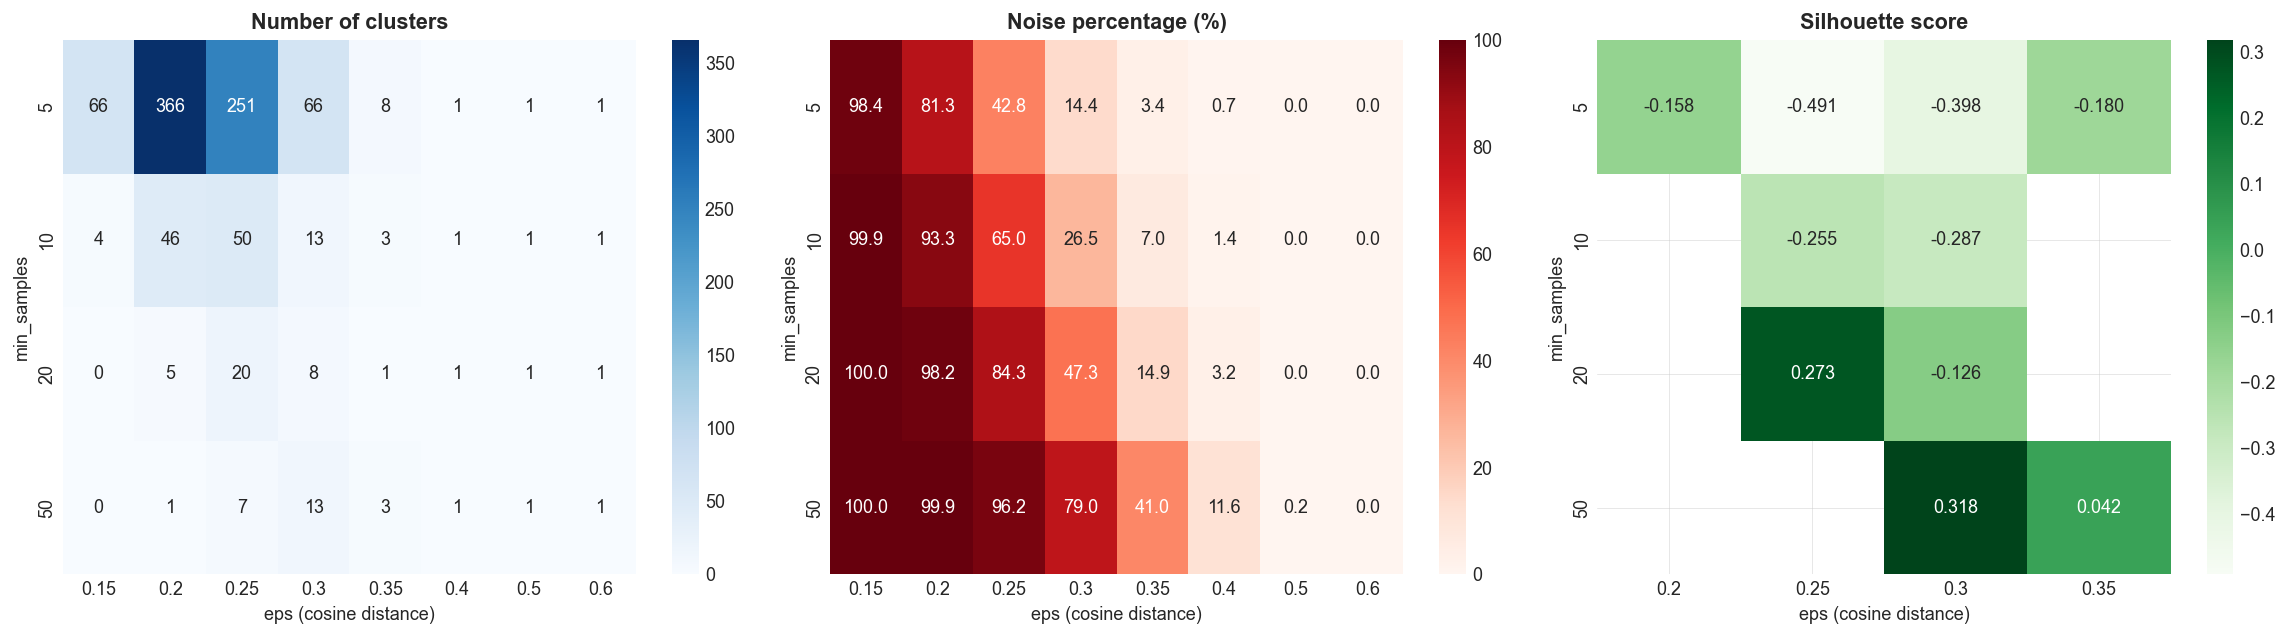


Best DBSCAN by silhouette:
  eps=0.3, min_samples=50.0 | clusters=13 | noise=79.0% | silhouette=0.31779998540878296


In [6]:
plot_dbscan_results(dbscan_results)

In [7]:
best_dbscan = dbscan_results.dropna(subset=["silhouette"])
if len(best_dbscan) > 0:
    best_row = best_dbscan.loc[best_dbscan["silhouette"].idxmax()]
    BEST_EPS = best_row["eps"]
    BEST_MIN_SAMPLES = int(best_row["min_samples"])
    print(f"Best DBSCAN params: eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES}")
    print(f"  Clusters: {int(best_row['n_clusters'])} | "
          f"Noise: {best_row['noise_pct']}% | "
          f"Silhouette: {best_row['silhouette']}")
else:
    BEST_EPS = 0.5
    BEST_MIN_SAMPLES = 10
    print("No valid DBSCAN config found — using defaults")

Best DBSCAN params: eps=0.3, min_samples=50
  Clusters: 13 | Noise: 79.0% | Silhouette: 0.31779998540878296


In [8]:
dbscan_labels = fit_final_dbscan(X_pca, eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES,
                                 n_components=8)

✓ Final DBSCAN fitted  (eps=0.3, min_samples=50)
  Clusters found : 13
  Noise points   : 39,489 (79.0%)
  Cluster sizes:
    Cluster 0: 2,543 profiles (5.1%)
    Cluster 1: 1,733 profiles (3.5%)
    Cluster 2: 2,886 profiles (5.8%)
    Cluster 3: 771 profiles (1.5%)
    Cluster 4: 1,224 profiles (2.4%)
    Cluster 5: 191 profiles (0.4%)
    Cluster 6: 374 profiles (0.7%)
    Cluster 7: 121 profiles (0.2%)
    Cluster 8: 461 profiles (0.9%)
    Cluster 9: 42 profiles (0.1%)
    Cluster 10: 72 profiles (0.1%)
    Cluster 11: 42 profiles (0.1%)
    Cluster 12: 51 profiles (0.1%)


In [9]:
df_original["dbscan_cluster"] = dbscan_labels

clusters_dir = os.path.join(PROJECT_ROOT, "outputs", "clusters")
for cluster_id in sorted(set(dbscan_labels) - {-1}):
    subset = df_original[df_original["dbscan_cluster"] == cluster_id]
    out_path = os.path.join(clusters_dir,
                            f"dbscan_cluster_{cluster_id}_profiles.csv")
    subset.to_csv(out_path, index=False)

noise_subset = df_original[df_original["dbscan_cluster"] == -1]
if len(noise_subset) > 0:
    noise_path = os.path.join(clusters_dir, "dbscan_noise_profiles.csv")
    noise_subset.to_csv(noise_path, index=False)

print(f"DBSCAN cluster CSVs saved")

DBSCAN cluster CSVs saved


In [10]:
dbscan_summary = profile_clusters(dbscan_labels, df_original, skill_vocab)
print("DBSCAN Cluster summary:")
print(dbscan_summary.to_string(index=False))

DBSCAN Cluster summary:
 cluster  size  pct_of_total                                                            top_skills  dominant_industry        dominant_role  median_exp top_seniority
      -1 39489          79.0                    python, sql, statistics, machine learning, tableau          Aerospace Full Stack Developer        5.40           mid
       0  2543           5.1 e-learning, instructional design, curriculum development, lms, moodle          Education    Software Engineer        5.10           mid
       1  1733           3.5       seo, content strategy, css, video editing, adobe creative suite              Media       Technical Lead        4.90           mid
       2  2886           5.8                                   docker, kubernetes, java, cicd, api Telecommunications          ML Engineer        4.70         entry
       3   771           1.5                   plc, lean manufacturing, iot, six sigma, automation      Manufacturing          ML Engineer        2.80 

## 3. Algorithm Comparison — K-Means vs DBSCAN

Both algorithms are evaluated using the same three intrinsic metrics:

| Metric | What it measures | Better when |
|---|---|---|
| Silhouette Score | Cohesion vs separation | Higher (max 1.0) |
| Davies-Bouldin Index | Average cluster similarity | Lower (min 0.0) |
| Calinski-Harabasz Index | Between/within cluster variance ratio | Higher |

Note: DBSCAN may produce noise points (-1). These are excluded from
silhouette computation but included in Davies-Bouldin and Calinski-Harabasz.

In [11]:
kmeans_metrics = evaluate_clustering(X_pca, kmeans_labels)
dbscan_metrics = evaluate_clustering(X_pca, dbscan_labels)

comparison_df = compare_algorithms({
    "K-Means": kmeans_metrics,
    "DBSCAN": dbscan_metrics,
})

print("=" * 70)
print("ALGORITHM COMPARISON")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

ALGORITHM COMPARISON
algorithm  silhouette  davies_bouldin  calinski_harabasz  n_clusters  n_noise
  K-Means      0.1449          1.9919            1910.26          15        0
   DBSCAN      0.1042          3.2061             454.97          13    39489


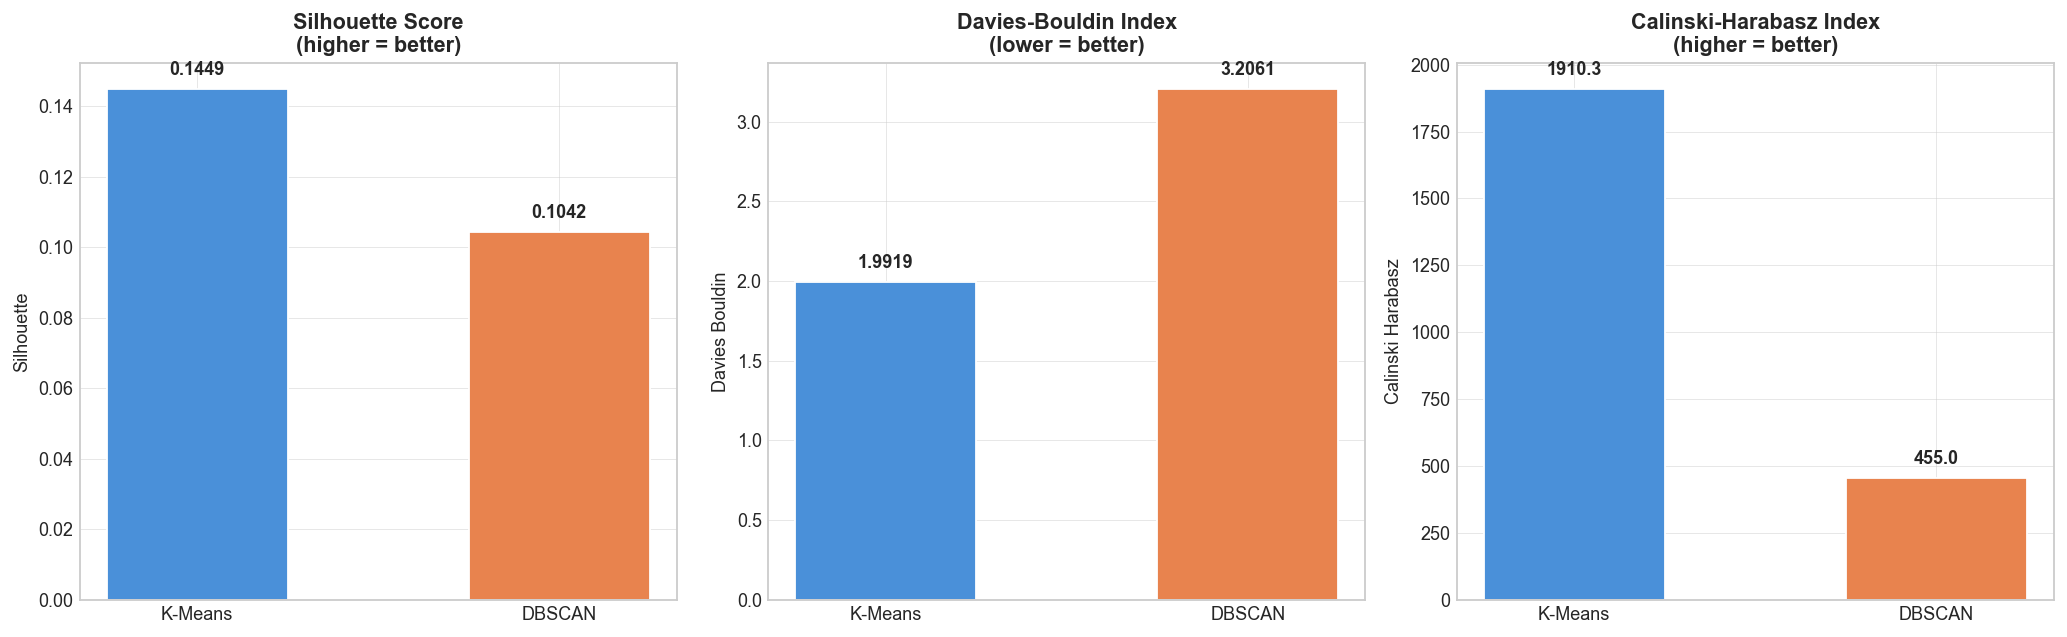


Comparison plot saved → outputs/plots/12_algorithm_comparison.png


In [12]:
metrics_to_plot = ["silhouette", "davies_bouldin", "calinski_harabasz"]
metrics_labels = [
    "Silhouette Score\n(higher = better)",
    "Davies-Bouldin Index\n(lower = better)",
    "Calinski-Harabasz Index\n(higher = better)"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_kmeans = "#4A90D9"
colors_dbscan = "#E8834E"

for i, (metric, label) in enumerate(zip(metrics_to_plot, metrics_labels)) :
    values = comparison_df[metric].values
    bars = axes[i].bar(
        ["K-Means", "DBSCAN"], values,
        color=[colors_kmeans, colors_dbscan],
        edgecolor="white", width=0.5
    )
    for bar, val in zip(bars, values):
        if not np.isnan(val) and val is not None:
            axes[i].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + (max(np.nan_to_num(values))*0.02 if max(np.nan_to_num(values)) > 0 else 0.01),
                         f"{val:.4f}" if metric != "calinski_harabasz" else f"{val:.1f}",
                         ha="center", va="bottom", fontsize=10, fontweight="bold")
    axes[i].set_title(label, fontsize=12, fontweight="bold")
    axes[i].set_ylabel(metric.replace("_", " ").title())

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "12_algorithm_comparison.png"))
plt.show()

print("\nComparison plot saved → outputs/plots/12_algorithm_comparison.png")

### 3a. Cluster Size Distribution Comparison

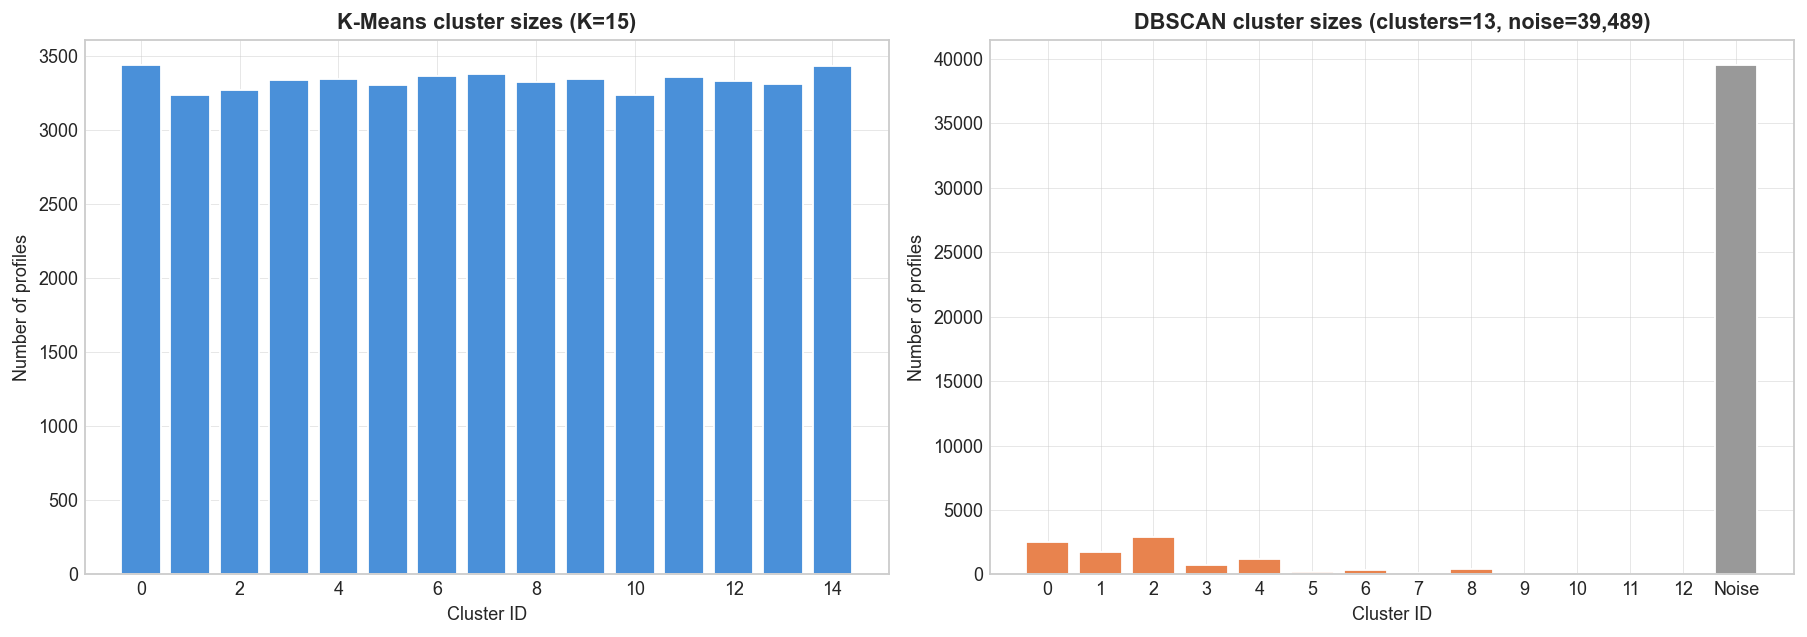

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kmeans_sizes = [kmeans_metrics["cluster_sizes"].get(i, 0)
                for i in range(kmeans_metrics["n_clusters"])]
axes[0].bar(range(len(kmeans_sizes)), kmeans_sizes,
            color=colors_kmeans, edgecolor="white")
axes[0].set_title(f"K-Means cluster sizes (K={kmeans_metrics['n_clusters']})",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Cluster ID")
axes[0].set_ylabel("Number of profiles")

dbscan_clusters = sorted([k for k in dbscan_metrics["cluster_sizes"].keys()
                          if k != "noise"])
dbscan_sizes = [dbscan_metrics["cluster_sizes"].get(k, 0) for k in dbscan_clusters]
axes[1].bar(range(len(dbscan_sizes)), dbscan_sizes,
            color=colors_dbscan, edgecolor="white")
noise_count = dbscan_metrics["cluster_sizes"].get("noise", 0)
if noise_count > 0:
    axes[1].bar(len(dbscan_sizes), noise_count,
                color="#999999", edgecolor="white")
    axes[1].set_xticks(list(range(len(dbscan_sizes))) + [len(dbscan_sizes)])
    axes[1].set_xticklabels(
        [str(k) for k in dbscan_clusters] + ["Noise"]
    )
else:
    axes[1].set_xticks(range(len(dbscan_sizes)))
    axes[1].set_xticklabels([str(k) for k in dbscan_clusters])

axes[1].set_title(
    f"DBSCAN cluster sizes (clusters={len(dbscan_clusters)}, "
    f"noise={noise_count:,})",
    fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Number of profiles")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "13_cluster_size_comparison.png"))
plt.show()

### 3b. t-SNE Visual Comparison

In [18]:
print("Running t-SNE for comparison visualisation...")
tsne = TSNE(n_components=2, random_state=42, perplexity=40,
            n_iter=1000)
X_tsne = tsne.fit_transform(X_pca)
print("t-SNE complete.")

Running t-SNE for comparison visualisation...
t-SNE complete.


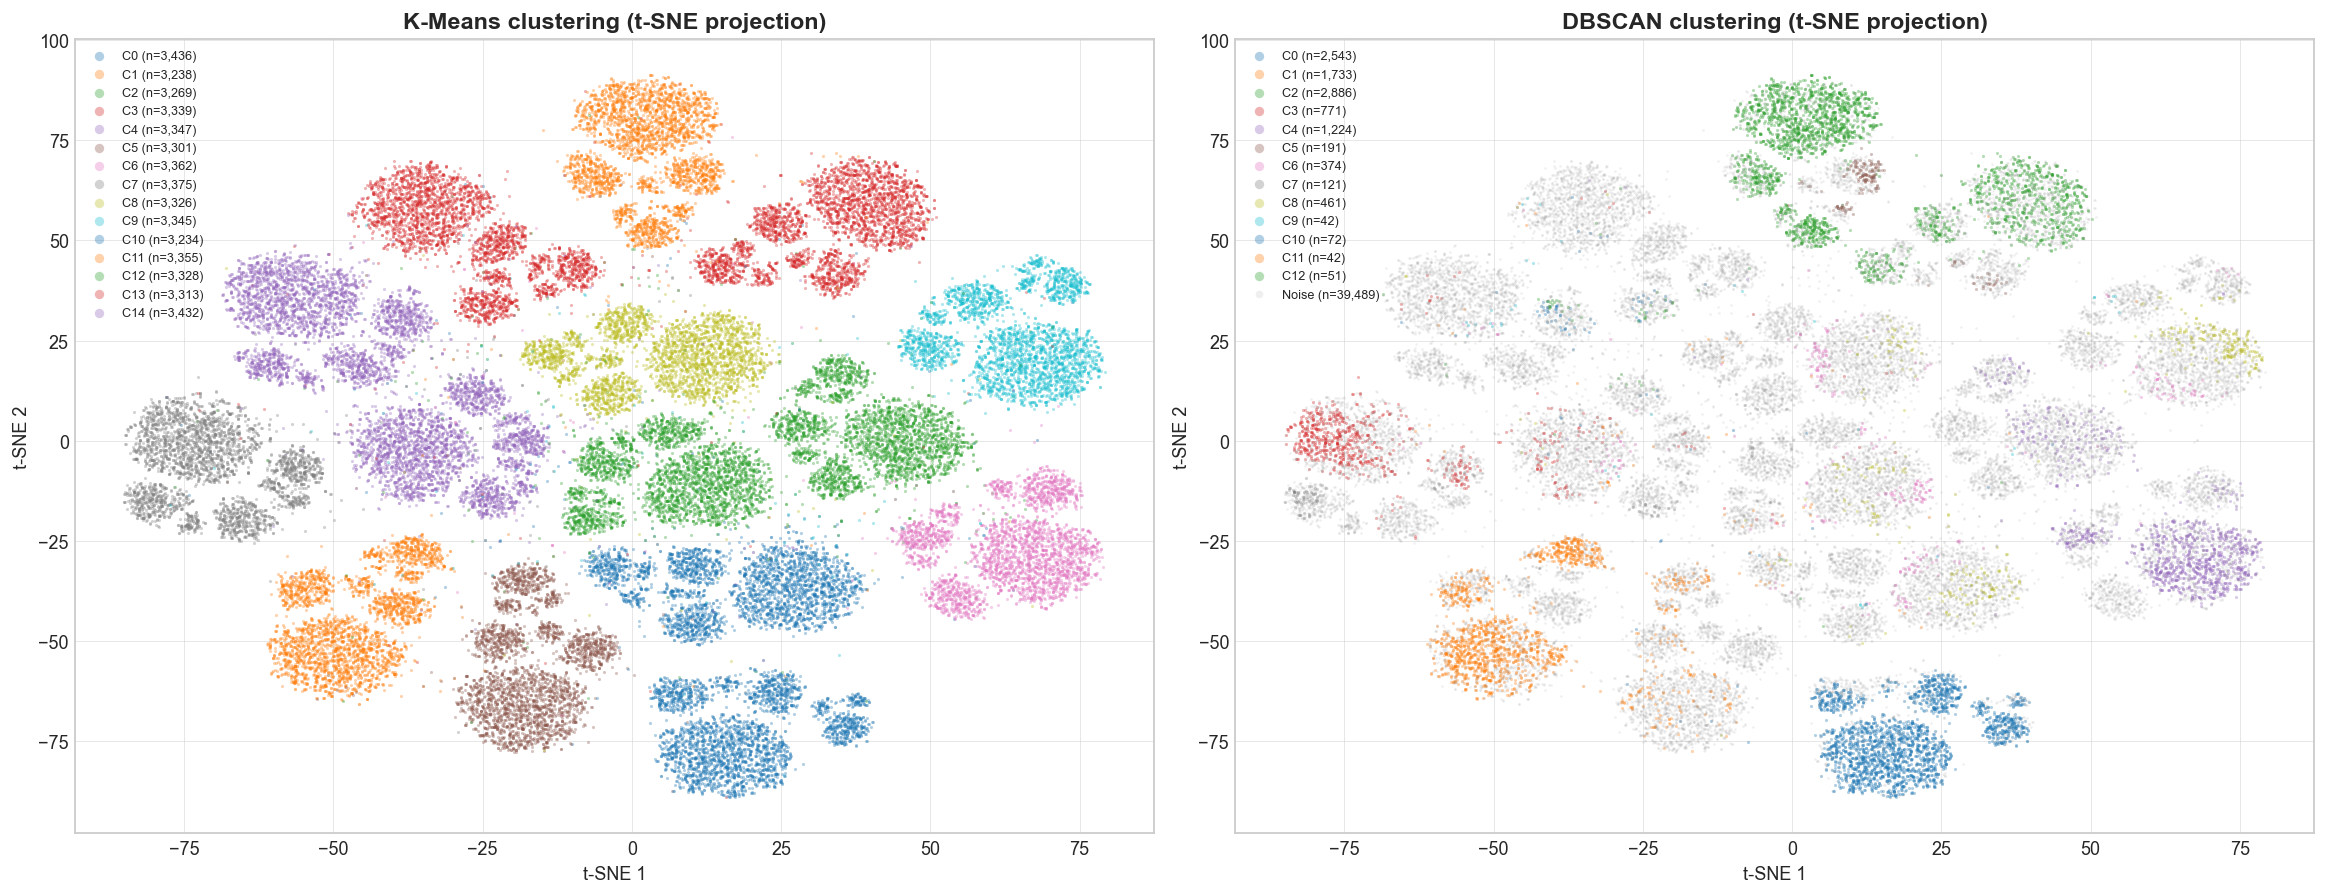

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# =========================
# K-MEANS PLOT
# =========================
unique_km_clusters = np.unique(kmeans_labels)
palette_km = sns.color_palette("tab10", n_colors=len(unique_km_clusters))

for i, cid in enumerate(unique_km_clusters):
    mask = kmeans_labels == cid
    if mask.sum() == 0:
        continue  # skip empty clusters

    axes[0].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=[palette_km[i]],
        label=f"C{cid} (n={mask.sum():,})",
        alpha=0.35,
        s=3,
        linewidths=0
    )

axes[0].set_title("K-Means clustering (t-SNE projection)",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

# Safe legend
if axes[0].has_data():
    axes[0].legend(markerscale=3, fontsize=7, loc="upper left")


# =========================
# DBSCAN PLOT
# =========================
unique_dbscan_clusters = np.unique(dbscan_labels)
dbscan_clusters = [c for c in unique_dbscan_clusters if c != -1]  # exclude noise

palette_db = sns.color_palette("tab10", n_colors=max(len(dbscan_clusters), 10))

for i, cid in enumerate(dbscan_clusters):
    mask = dbscan_labels == cid
    if mask.sum() == 0:
        continue  # skip empty clusters

    axes[1].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=[palette_db[i % 10]],
        label=f"C{cid} (n={mask.sum():,})",
        alpha=0.35,
        s=3,
        linewidths=0
    )

# Plot noise separately
noise_mask = dbscan_labels == -1
noise_count = noise_mask.sum()

if noise_count > 0:
    axes[1].scatter(
        X_tsne[noise_mask, 0],
        X_tsne[noise_mask, 1],
        c=["#999999"],
        label=f"Noise (n={noise_count:,})",
        alpha=0.15,
        s=2,
        linewidths=0
    )

axes[1].set_title("DBSCAN clustering (t-SNE projection)",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

# Safe legend
if axes[1].has_data():
    axes[1].legend(markerscale=3, fontsize=7, loc="upper left")


# =========================
# SAVE + SHOW
# =========================
plt.tight_layout()

os.makedirs(PLOTS_DIR, exist_ok=True)  # ensure directory exists
plt.savefig(os.path.join(PLOTS_DIR, "13_tsne_comparison.png"), dpi=300)

plt.show()

## 4. Recommendation Demo — Test on a Real Profile

We pick a specific profile and find the 5 most compatible profiles
using the K-Means clustering + cosine similarity pipeline.

In [20]:
QUERY_IDX = 42

query = df_original.iloc[QUERY_IDX]
print("=" * 60)
print("QUERY PROFILE")
print("=" * 60)
print(f"Profile ID      : {query['profile_id']}")
print(f"Name            : {query['name']}")
print(f"Role            : {query['current_role']}")
print(f"Company         : {query['current_company']}")
print(f"Industry        : {query['industry']}")
print(f"Seniority       : {query['seniority_level']}")
print(f"Experience      : {query['years_experience']} years")
print(f"Connections     : {query['connections']:,}")
print(f"Location        : {query['location']}")
print(f"Remote pref     : {query['remote_preference']}")
print(f"Skills          : {query['skills']}")
print(f"Goals           : {query['goals']}")
print(f"Needs           : {query['needs']}")
print(f"Can offer       : {query['can_offer']}")
print(f"K-Means Cluster : {int(kmeans_labels[QUERY_IDX])}")
print(f"DBSCAN Cluster  : {int(dbscan_labels[QUERY_IDX])}")

QUERY PROFILE
Profile ID      : PROF-00043
Name            : William Harris
Role            : Scrum Master
Company         : Wells Fargo
Industry        : Media
Seniority       : entry
Experience      : 2.4 years
Connections     : 175
Location        : San Francisco, NC
Remote pref     : onsite
Skills          : ['sql', 'biostatistics', 'spss', 'node.js']
Goals           : ['job opportunities']
Needs           : ['research opportunities', 'project collaboration', 'job referrals']
Can offer       : ['skill training', 'network connections', 'leadership coaching']
K-Means Cluster : 1
DBSCAN Cluster  : -1


In [21]:
df_original["cluster"] = kmeans_labels

recommendations = recommend_profiles(
    query_idx   = QUERY_IDX,
    X           = X,
    labels      = kmeans_labels,
    df_original = df_original,
    top_n       = 5
)

print("=" * 60)
print(f"TOP 5 COMPATIBLE PROFILES  (K-Means Cluster {int(kmeans_labels[QUERY_IDX])})")
print("=" * 60)

for rank, (_, row) in enumerate(recommendations.iterrows(), start=1):
    print(f"\n{'─' * 60}")
    print(f"Rank {rank}  —  similarity score: {row['similarity_score']:.4f}")
    print(f"  Name        : {row['name']}")
    print(f"  Role        : {row['current_role']}")
    print(f"  Company     : {row['current_company']}")
    print(f"  Industry    : {row['industry']}")
    print(f"  Seniority   : {row['seniority_level']}")
    print(f"  Experience  : {row['years_experience']} years")
    print(f"  Location    : {row['location']}")
    print(f"  Skills      : {row['skills']}")
    print(f"  Goals       : {row['goals']}")
    print(f"  Needs       : {row['needs']}")
    print(f"  Can offer   : {row['can_offer']}")

print(f"\n{'=' * 60}")

TOP 5 COMPATIBLE PROFILES  (K-Means Cluster 1)

────────────────────────────────────────────────────────────
Rank 1  —  similarity score: 0.6146
  Name        : John Martinez
  Role        : ML Engineer
  Company     : Salesforce
  Industry    : Media
  Seniority   : entry
  Experience  : 2.2 years
  Location    : Charlotte, Germany
  Skills      : ['biostatistics', 'simulation', 'html', 'node.js']
  Goals       : ['networking']
  Needs       : ['peer feedback']
  Can offer   : ['research expertise']

────────────────────────────────────────────────────────────
Rank 2  —  similarity score: 0.6093
  Name        : Jessica Nguyen
  Role        : Backend Developer
  Company     : Wells Fargo
  Industry    : Media
  Seniority   : entry
  Experience  : 1.3 years
  Location    : Seattle, Singapore
  Skills      : ['machine learning', 'matlab', 'sql', 'node.js', 'marketing', 'biostatistics']
  Goals       : ['networking', 'startup advice', 'technical expertise']
  Needs       : ['career advice

## 5. Final Summary

In [22]:
print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"\nDataset            : {len(df_original):,} profiles")
print(f"Features           : {X.shape[1]} (after preprocessing)")
print(f"PCA dimensions     : {X_pca.shape[1]} "
      f"({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
print(f"\n{'─' * 70}")
print(comparison_df.to_string(index=False))
print(f"{'─' * 70}")

best_algo = comparison_df.loc[comparison_df["silhouette"].idxmax(), "algorithm"]
print(f"\nBest algorithm by silhouette score: {best_algo}")
print(f"\nAll plots saved to: {PLOTS_DIR}")
print(f"All cluster CSVs saved to: {os.path.join(PROJECT_ROOT, 'outputs', 'clusters')}")

FINAL RESULTS SUMMARY

Dataset            : 50,000 profiles
Features           : 188 (after preprocessing)
PCA dimensions     : 30 (31.3% variance)

──────────────────────────────────────────────────────────────────────
algorithm  silhouette  davies_bouldin  calinski_harabasz  n_clusters  n_noise
  K-Means      0.1449          1.9919            1910.26          15        0
   DBSCAN      0.1042          3.2061             454.97          13    39489
──────────────────────────────────────────────────────────────────────

Best algorithm by silhouette score: K-Means

All plots saved to: /Users/yugjain/Documents/ML_ASS/unsupervised-professional-matching/outputs/plots
All cluster CSVs saved to: /Users/yugjain/Documents/ML_ASS/unsupervised-professional-matching/outputs/clusters
